In [1]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3
import base64
from io import BytesIO
from PIL import Image

In [2]:
DB = "subscriptions.db"

with sqlite3.connect(DB) as conn:
    cursor = conn.cursor()
    cursor.execute('CREATE TABLE IF NOT EXISTS subscriptions (type TEXT PRIMARY KEY, price REAL)')
    conn.commit()

In [3]:
def get_sub_price(type):
    print(f"DATABASE TOOL CALLED: Getting price for{type}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price from subscriptions WHERE type = ?', (type.lower(),))
        result = cursor.fetchone()
        return f"subscription price for {type} is EGP{result[0]}" if result else "Subscription type not found."

In [4]:
def set_sub_price(type, price):
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('INSERT OR REPLACE INTO subscriptions (type, price) VALUES (?, ?)', (type.lower(), price))
        conn.commit()

In [5]:
sub_prices = {
    "silver": 350,
    "gold": 750,
    "platinum": 1100
}
for type, price in sub_prices.items():
    set_sub_price(type, price)

In [6]:
get_sub_price("Gold")

DATABASE TOOL CALLED: Getting price forGold


'subscription price for Gold is EGP750.0'

In [7]:
# Initialization

load_dotenv(override=True)

openai_api_key = os.getenv('OPENAI_API_KEY')
if openai_api_key:
    print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
else:
    print("OpenAI API Key not set")
    
MODEL = "gpt-4.1-mini"
openai = OpenAI()

DB = "subscriptions.db"

OpenAI API Key exists and begins sk-proj-


In [8]:
system_message = """
You are a helpful customer support assistant for Octa Gym in Cairo, Egypt.
Reply briefly, clearly, and politely.
If the customer asks about the price of a subscription plan, use the available tool.
If the customer asks generally about subscriptions, mention the available plans: Silver, Gold, and Platinum.
"""

In [9]:
subscription_price_function = {
    "name": "get_subscription_price",
    "description": "Get the price of a gym subscription plan from the database.",
    "parameters": {
        "type": "object",
        "properties": {
            "subscription_type": {
                "type": "string",
                "description": "The gym subscription type, for example: silver, gold, platinum, or any future plan stored in the database."
            }
        },
        "required": ["subscription_type"],
        "additionalProperties": False
    }
}

tools = [{"type": "function", "function": subscription_price_function}]

In [10]:
def chat(message, history):
    history = [{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

In [11]:
def handle_tool_calls(message):
    responses = []

    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_subscription_price":
            args = json.loads(tool_call.function.arguments)
            subscription_type = args.get("subscription_type")

            price_details = get_sub_price(subscription_type)

            responses.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": price_details
            })

    return responses

In [12]:
gr.ChatInterface(fn=chat, type="messages").launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://93e235ced06aa1309f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
def pic(type):
    image_response = openai.images.generate(
        model = "dall-e-3",
        prompt= f" an image representing the subscription plan {type} for a gym, showing the benfites of the plan, and the price in EGP about this {type}, in a vibrant pop-art style",
        size="1024x1024",
        n=1,
        response_format="b64_json",
    )
    image_base64 = image_response.data[0].b64_json
    image_data = base64.b64decode(image_base64)
    return Image.open(BytesIO(image_data))

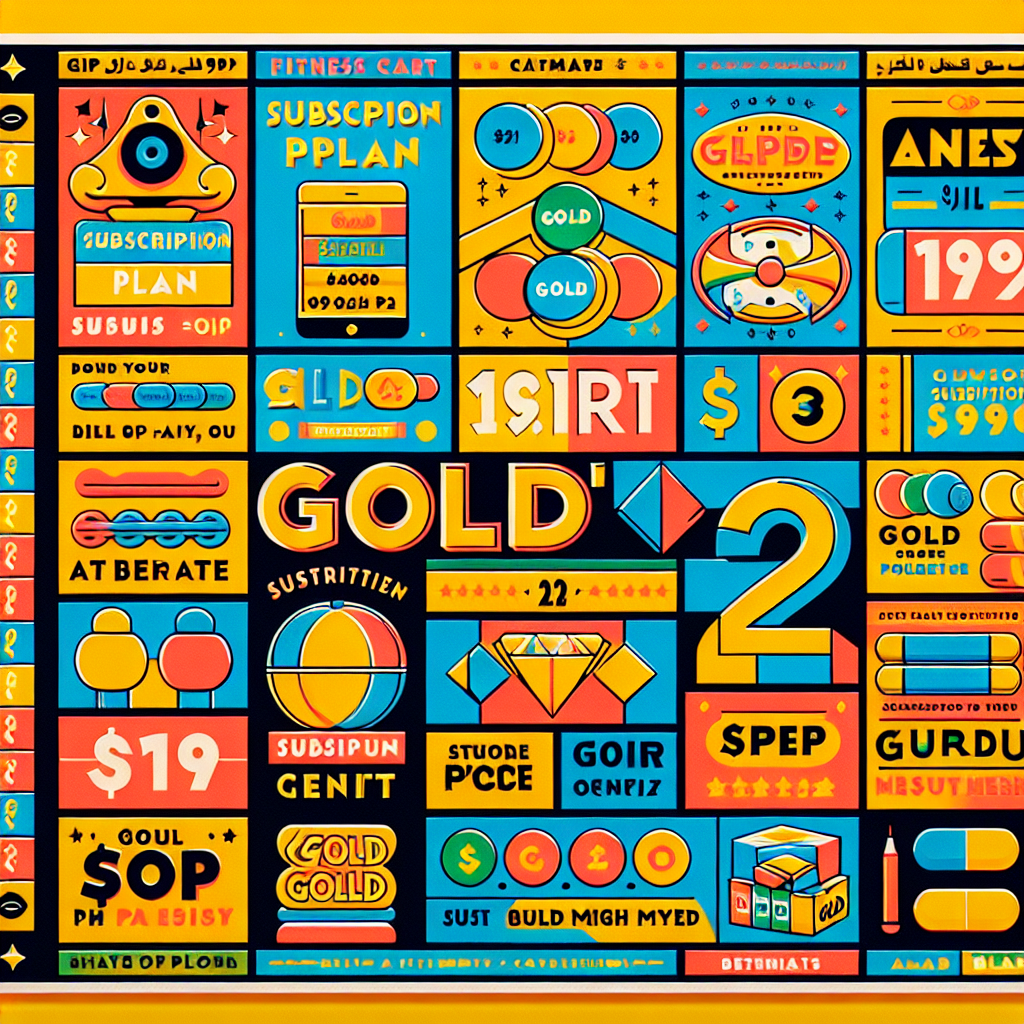

In [14]:
image = pic("Gold")
display(image)

In [15]:
def talker(message):
    response = openai.audio.speech.create(
      model="gpt-4o-mini-tts",
      voice="onyx", 
      input=message
    )
    return response.content

## Octa Gym model AI assistant with Image and audio generation

In [16]:
def chat(history):
    history =[{"role":h["role"], "content":h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    types =[]
    image = None

    while response.choices[0].finish_reason=="tool_calls":
        message = response.choices[0].message
        responses, types = handle_tool_calls_and_return_types(message)
        messages.append(message)
        messages.extend(responses)
        response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)


    reply = response.choices[0].message.content
    history += [{"role": "assistant", "content": reply}]

    voice = talker(reply)

    if types:
        image = pic(types[0])
    return history, voice, image        
    

In [17]:
def handle_tool_calls_and_return_types(message):
    responses = []
    types = []

    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_subscription_price":
            arguments = json.loads(tool_call.function.arguments)
            type = arguments.get("subscription_type")
            types.append(type)
            price_details = get_sub_price(type)
           

            responses.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": price_details
            })

    return responses, types

In [18]:
# Callbacks (along with the chat() function above)

def put_message_in_chatbot(message, history):
        return "", history + [{"role":"user", "content":message}]

# UI definition

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

# Hooking up events to callbacks

    message.submit(put_message_in_chatbot, inputs=[message, chatbot], outputs=[message, chatbot]).then(
        chat, inputs=chatbot, outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True, auth=("octa", "gym"), share=True)

* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://666be71d6dee1c36cb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
